Paso 1:

Cargar los datos

In [32]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.txt')          # matriz 100 x 3
X = data[:, :2]                        # columnas 0 y 1 → puntos (x1, x2)
y = data[:, 2]                         # columna 2 → etiqueta (0 o 1)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nPrimeras 5 filas (como en la tarea):")
print(data[:5])

Forma de X: (100, 2)
Forma de y: (100,)

Primeras 5 filas (como en la tarea):
[[ 1.3   -0.54   1.   ]
 [-2.3   -2.5    1.   ]
 [-0.37  -0.047  1.   ]
 [ 0.49   0.79   1.   ]
 [ 1.     0.95   1.   ]]


Paso 2:

Definimos la funcion sigmoidal y la funcion de costo (binary cross-entropy)

In [33]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(theta, X, y):
    m = len(y)
    z = np.dot(X, theta)
    h = sigmoid(z)
    # Evitamos log(0) con un pequeño epsilon
    epsilon = 1e-8
    J = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return J

Paso 3:

Implementamos la funcion de Descenso de gradiente

In [34]:
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        z = np.dot(X, theta)
        h = sigmoid(z)
        gradient = (1/m) * np.dot(X.T, (h - y))
        theta = theta - alpha * gradient
        cost = cost_function(theta, X, y)
        cost_history.append(cost)

        if i % 100 == 0:  # imprimir cada 20 iteraciones
            print(f"Iteración {i:3d} | Costo: {cost:.4f}")

    return theta, cost_history

Paso 4:

Inicializamos los parametros tal y como se indica (aleatorios en (-0.01, 0.01)) y el bias. Luego configuramos hiperparametros (alpha y numero de epocas). Finalmente entrenamos.

In [37]:
X_bias = np.c_[np.ones((X.shape[0], 1)), X]

np.random.seed(42)
theta_init = np.random.uniform(-0.01, 0.01, 3)

print("Parámetros iniciales (aleatorios):", theta_init)

alpha = 0.5
iterations = 1000

theta_final, cost_history = gradient_descent(X_bias, y, theta_init.copy(), alpha, iterations)

print("\nParámetros finales (θ0, θ1, θ2):", theta_final)
print("Costo final:", cost_history[-1])

Parámetros iniciales (aleatorios): [-0.0025092   0.00901429  0.00463988]
Iteración   0 | Costo: 0.4001
Iteración 100 | Costo: 0.0645
Iteración 200 | Costo: 0.0419
Iteración 300 | Costo: 0.0327
Iteración 400 | Costo: 0.0275
Iteración 500 | Costo: 0.0240
Iteración 600 | Costo: 0.0215
Iteración 700 | Costo: 0.0196
Iteración 800 | Costo: 0.0181
Iteración 900 | Costo: 0.0169

Parámetros finales (θ0, θ1, θ2): [ 7.04329142 -0.96357906  2.92228578]
Costo final: 0.015897597774976298


Paso 5:

Mostrar resultados del entrenamiento

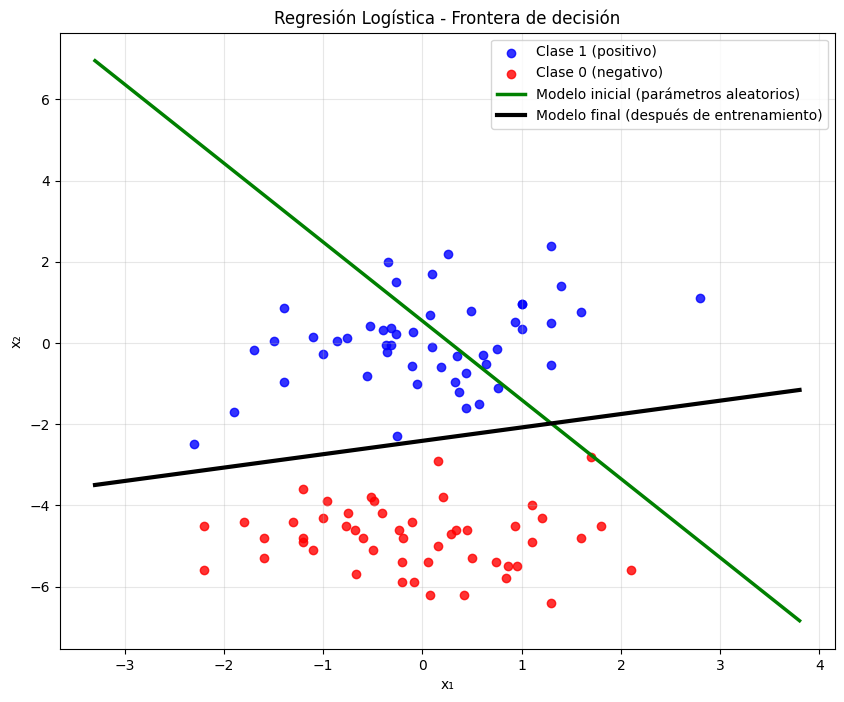

In [40]:
plt.figure(figsize=(10, 8))

# Puntos de datos
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Clase 1 (positivo)', alpha=0.8)
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red',  label='Clase 0 (negativo)', alpha=0.8)

# Línea del modelo inicial (verde)
x1_plot = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)

def decision_boundary(theta, x1):
    return -(theta[0] + theta[1] * x1) / theta[2]

x2_init = decision_boundary(theta_init, x1_plot)
plt.plot(x1_plot, x2_init, 'g-', linewidth=2.5, label='Modelo inicial (parámetros aleatorios)')

# Línea del modelo final (negra)
x2_final = decision_boundary(theta_final, x1_plot)
plt.plot(x1_plot, x2_final, 'k-', linewidth=3, label='Modelo final (después de entrenamiento)')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Regresión Logística - Frontera de decisión')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()